# Bank Marketing — Classification Problem (Term Deposit Prediction)

**Course:** TC6414 Data Knowledge Discovery and Data Mining

Group members:

ZHANG CHENCHUAN(P162614)

GUO ZEGUI

ZHANG JINGJING

**Task:** Binary classification — will a client subscribe to a term deposit (`y` = yes/no)?

**Dataset:** Portuguese bank telephone marketing campaigns (Moro et al., 2014).https://www.kaggle.com/datasets/henriqueyamahata/bank-marketing/data


## 1. Imports

In [51]:
# Core data libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# scikit-learn: split, preprocessing, cross-validation tools
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.over_sampling import SMOTE      # synthetic minority oversampling (train only)

# scikit-learn: the two models we compare
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# scikit-learn: evaluation metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, confusion_matrix)

sns.set_style("whitegrid")
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Configuration 

In [ ]:
# ============================================================================
# CONFIGURATION — edit values here
# ============================================================================

# Reproducibility: a fixed seed so everyone gets the SAME results.
RANDOM_SEED = 42

# --- PROJECT LOCATION ------------------------------------------------------
# All paths below are built from PROJECT_ROOT, so you only change ONE thing.
#
# Local default: if this notebook runs from the "notebooks/" folder, the project
# root is its parent folder; otherwise we use the current working directory.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
#
# >>> GOOGLE COLAB: after mounting Google Drive, comment the line above and set
#     PROJECT_ROOT to your uploaded project folder, e.g.:
# from google.colab import drive; drive.mount('/content/drive')
# PROJECT_ROOT = Path('/content/drive/MyDrive/03 Project')
# ---------------------------------------------------------------------------

# Derived paths (do not hard-code anything below)
DATA_PATH = PROJECT_ROOT / "data" / "bank-additional-full.csv"
FIG_DIR   = PROJECT_ROOT / "outputs" / "figures"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# --- DATA / SPLIT SETTINGS -------------------------------------------------
TARGET    = "y"                 # name of the target column
DROP_COLS = ["duration"]        # leakage: only known after the call -> drop it
TEST_SIZE = 0.20                # 20% held out for testing
CV_FOLDS  = 5                   # cross-validation folds (on training set only)
RUN_PAIRPLOT = True             # set False to skip the (slow) pair plot
PAIRPLOT_SAMPLE = 1000          # rows sampled for the pair plot

# --- IMBALANCE / THRESHOLD SETTINGS ----------------------------------------
SMOTE_K_NEIGHBORS = 5           # SMOTE neighbours used to synthesise minority samples
THRESHOLD = 0.35                # custom decision threshold for Random Forest (default = 0.50)

# --- MODEL HYPERPARAMETERS -------------------------------------------------
# NOTE: we do NOT use class_weight='balanced' here, because we handle the
# imbalance with train-only upsampling instead (see the Upsampling section).
LOGREG_PARAMS = dict(
    max_iter=1000,
    random_state=RANDOM_SEED,
)
RF_PARAMS = dict(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,         # a little regularization to reduce overfitting
    random_state=RANDOM_SEED,
    n_jobs=-1,                  # use all CPU cores
)

# --- SMALL HELPERS to save outputs into the outputs/ folder ----------------
def save_fig(name, fig=None):
    # Save the current (or given) matplotlib figure into outputs/figures/
    fig = fig or plt.gcf()
    path = FIG_DIR / name
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"[saved figure] {path}")

def save_table(table, name, index=False):
    # Save a pandas DataFrame into outputs/tables/ as a CSV file
    path = TABLE_DIR / name
    table.to_csv(path, index=index)
    print(f"[saved table]  {path}")

print("PROJECT_ROOT :", PROJECT_ROOT)
print("DATA_PATH    :", DATA_PATH)
print("Data file found:", DATA_PATH.exists())
print("Random seed  :", RANDOM_SEED)

PROJECT_ROOT : /Users/zcc/Documents/ukm/12Data mining/03 Project
DATA_PATH    : /Users/zcc/Documents/ukm/12Data mining/03 Project/data/bank-additional-full.csv
Data file found: True
Random seed  : 42


## 3. Load the Data

In [53]:
# The CSV uses ';' as the separator (not ',').
df = pd.read_csv(DATA_PATH, sep=";")

print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 4. Exploratory Data Analysis (EDA)

Before changing anything for modeling, we explore the data to understand it: missing
values, the class balance, numeric distributions, and how some features relate to the
target. **Note:** `duration` appears in some EDA plots below. We keep it here only to
*understand* the data — it is **removed before modeling** because it is only known after
the call has ended (using it would leak the answer).

### 4.1 Replace `"unknown"` with `NaN`

This dataset stores missing values as the text `"unknown"` rather than a true blank.
We convert `"unknown"` to `NaN` now so the missing-value chart below is accurate and the
imputer can handle them later. (This is a safe step — it learns nothing from the data.)

In [54]:
# BEFORE: how many "unknown" values does each column have?
print("=== BEFORE: 'unknown' counts per column ===")
for col in df.select_dtypes(include='object').columns:
    n = (df[col] == 'unknown').sum()
    if n > 0:
        print(f"  {col}: {n}")

df = df.replace("unknown", np.nan)

# AFTER: the same values are now real NaNs
print("Duplicate rows:", df.duplicated().sum())
print("Total missing (NaN) values now:", int(df.isnull().sum().sum()))
print("=== AFTER: NaN counts per column ===")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nData types:")
print(df.dtypes)

=== BEFORE: 'unknown' counts per column ===
  job: 330
  marital: 80
  education: 1731
  default: 8597
  housing: 990
  loan: 990
Duplicate rows: 12
Total missing (NaN) values now: 12718
=== AFTER: NaN counts per column ===
job           330
marital        80
education    1731
default      8597
housing       990
loan          990
dtype: int64

Data types:
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object


### 4.2 Missing values

[saved table]  /Users/zcc/Documents/ukm/12Data mining/03 Project/outputs/tables/missing_values_summary.csv
[saved figure] /Users/zcc/Documents/ukm/12Data mining/03 Project/outputs/figures/missing_values.png


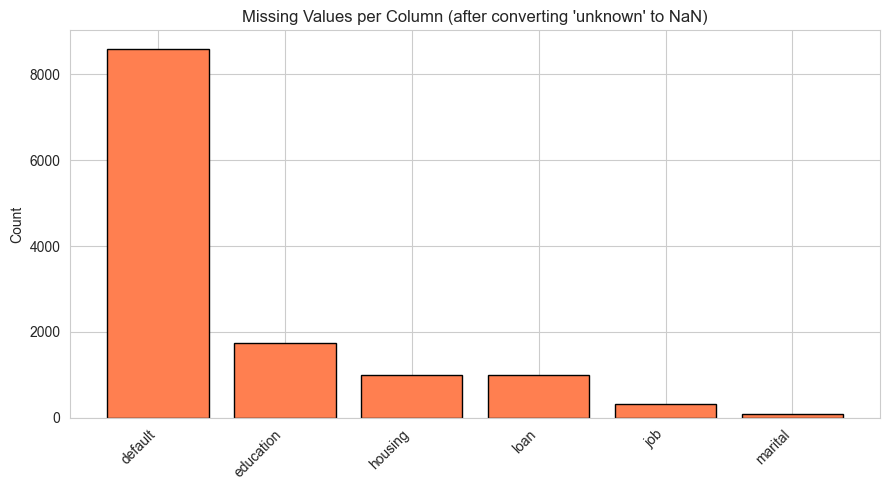

,column,missing_count,missing_percent
0,default,8597,20.87
1,education,1731,4.20
2,housing,990,2.40
3,loan,990,2.40
4,job,330,0.80
5,marital,80,0.19


In [55]:
# Build a small summary table of missing values per column
missing = df.isnull().sum()
missing_summary = (pd.DataFrame({
        "column": missing.index,
        "missing_count": missing.values,
        "missing_percent": (missing.values / len(df) * 100).round(2),
    })
    .query("missing_count > 0")
    .sort_values("missing_count", ascending=False)
    .reset_index(drop=True))
save_table(missing_summary, "missing_values_summary.csv")

# Bar chart of missing values per column
plt.figure(figsize=(9, 5))
plt.bar(missing_summary["column"], missing_summary["missing_count"],
        color="coral", edgecolor="black")
plt.title("Missing Values per Column (after converting 'unknown' to NaN)")
plt.ylabel("Count"); plt.xticks(rotation=45, ha="right")
plt.tight_layout()
save_fig("missing_values.png")
plt.show()

missing_summary

### 4.3 Target distribution (class balance)

[saved figure] /Users/zcc/Documents/ukm/12Data mining/03 Project/outputs/figures/target_distribution.png


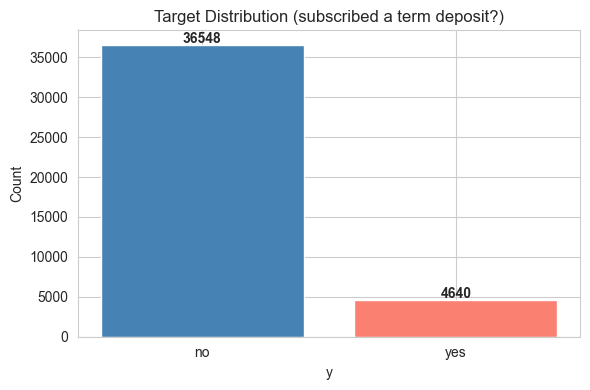

[saved table]  /Users/zcc/Documents/ukm/12Data mining/03 Project/outputs/tables/class_distribution_before_split.csv
Original class distribution (full dataset):
class  count  percent
   no  36548    88.73
  yes   4640    11.27


In [56]:
# How many clients said yes vs no?
counts = df[TARGET].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(counts.index, counts.values, color=["steelblue", "salmon"])
plt.title("Target Distribution (subscribed a term deposit?)")
plt.xlabel("y"); plt.ylabel("Count")
for i, v in enumerate(counts.values):
    plt.text(i, v + 200, str(v), ha="center", fontweight="bold")
plt.tight_layout()
save_fig("target_distribution.png")
plt.show()

# Save the original (full-data) class distribution as a table + print check
class_before = (df[TARGET].value_counts()
                .rename_axis("class").reset_index(name="count"))
class_before["percent"] = (class_before["count"] / len(df) * 100).round(2)
save_table(class_before, "class_distribution_before_split.csv")
print("Original class distribution (full dataset):")
print(class_before.to_string(index=False))

**Observation:** The data is heavily **imbalanced** — about **89% "no"** and only
**11% "yes"**. A model that always predicts "no" would score ~89% accuracy while being
useless, so we rely on **F1-score** and **ROC-AUC**, and we balance the **training set**
with upsampling later.

### 4.4 Numerical feature distributions

[saved figure] /Users/zcc/Documents/ukm/12Data mining/03 Project/outputs/figures/numerical_histograms.png


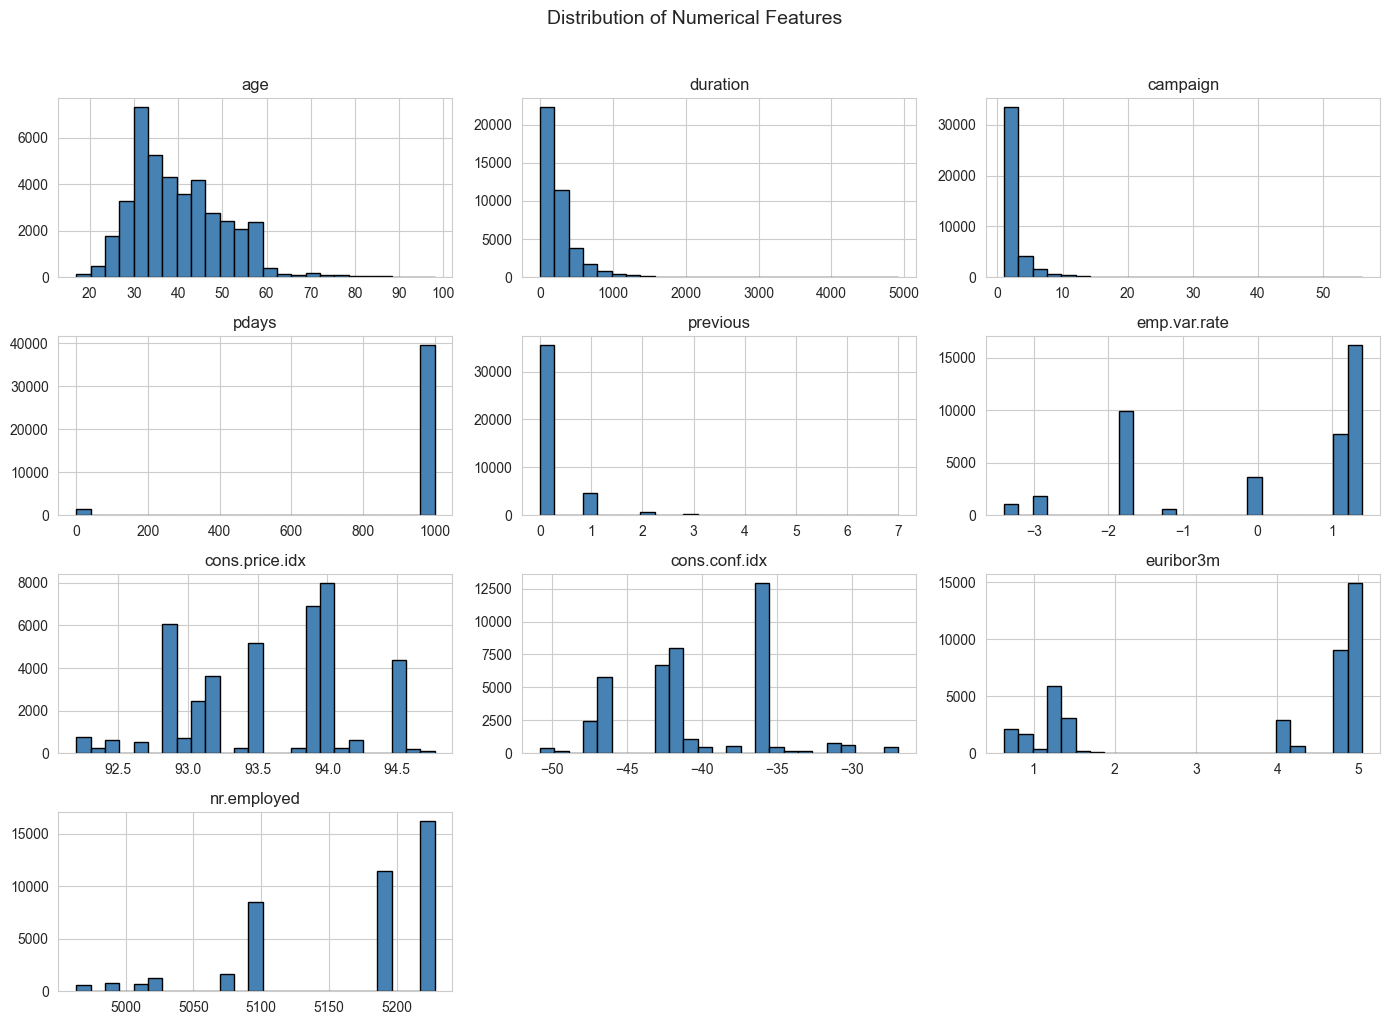

Numerical columns: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [57]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
df[num_cols].hist(figsize=(14, 10), bins=25, edgecolor="black", color="steelblue")
plt.suptitle("Distribution of Numerical Features", fontsize=14, y=1.02)
plt.tight_layout()
save_fig("numerical_histograms.png")
plt.show()
print("Numerical columns:", num_cols)

### 4.5 Correlation heatmap

[saved figure] /Users/zcc/Documents/ukm/12Data mining/03 Project/outputs/figures/correlation_heatmap.png


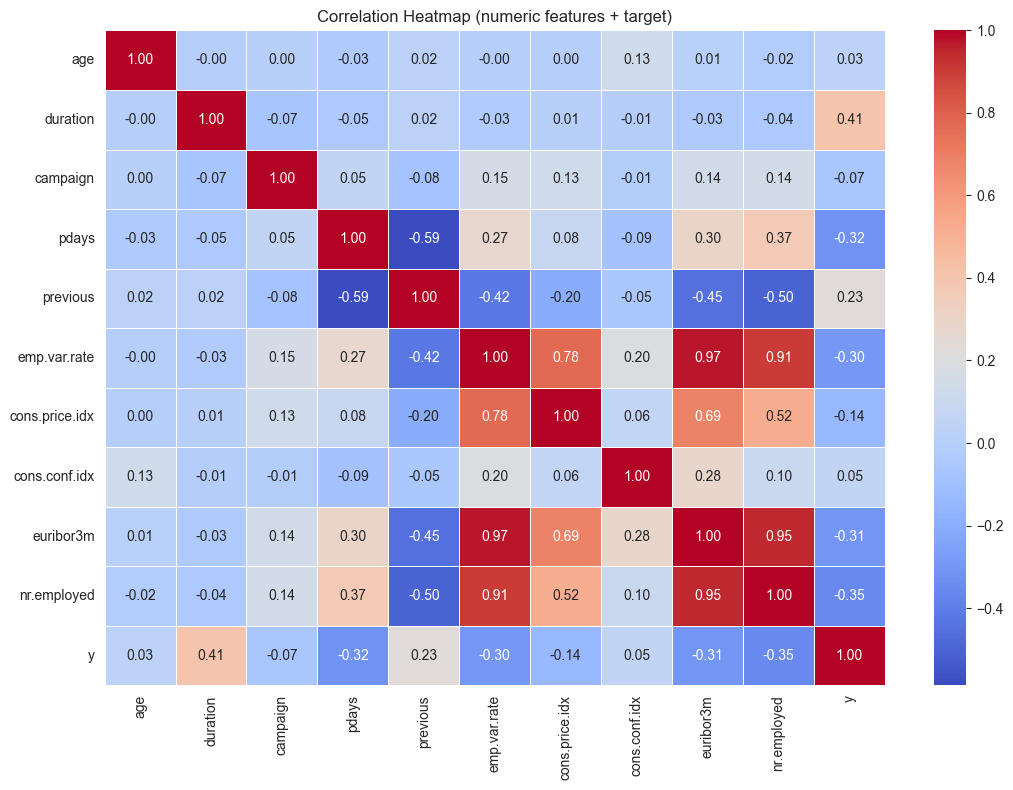

In [58]:
# Map y -> 1/0 only for this analysis (a temporary copy) so we can include the target.
df_eda = df.copy()
df_eda[TARGET] = (df_eda[TARGET] == "yes").astype(int)
corr = df_eda[num_cols + [TARGET]].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap (numeric features + target)")
plt.tight_layout()
save_fig("correlation_heatmap.png")
plt.show()

**Observation:** `duration` has by far the strongest correlation with the target. This is
exactly why it is dangerous: it is only known **after** the call, so it cannot be used for
a realistic "who should we call?" model. **We use it for exploration only and drop it
before modeling.** The next most informative features are the social/economic indicators
(`nr.employed`, `euribor3m`, `emp.var.rate`).

### 4.6 Pair plot of numerical features (optional, uses a 1000-row sample)

[saved figure] /Users/zcc/Documents/ukm/12Data mining/03 Project/outputs/figures/pairplot_numerical_features.png


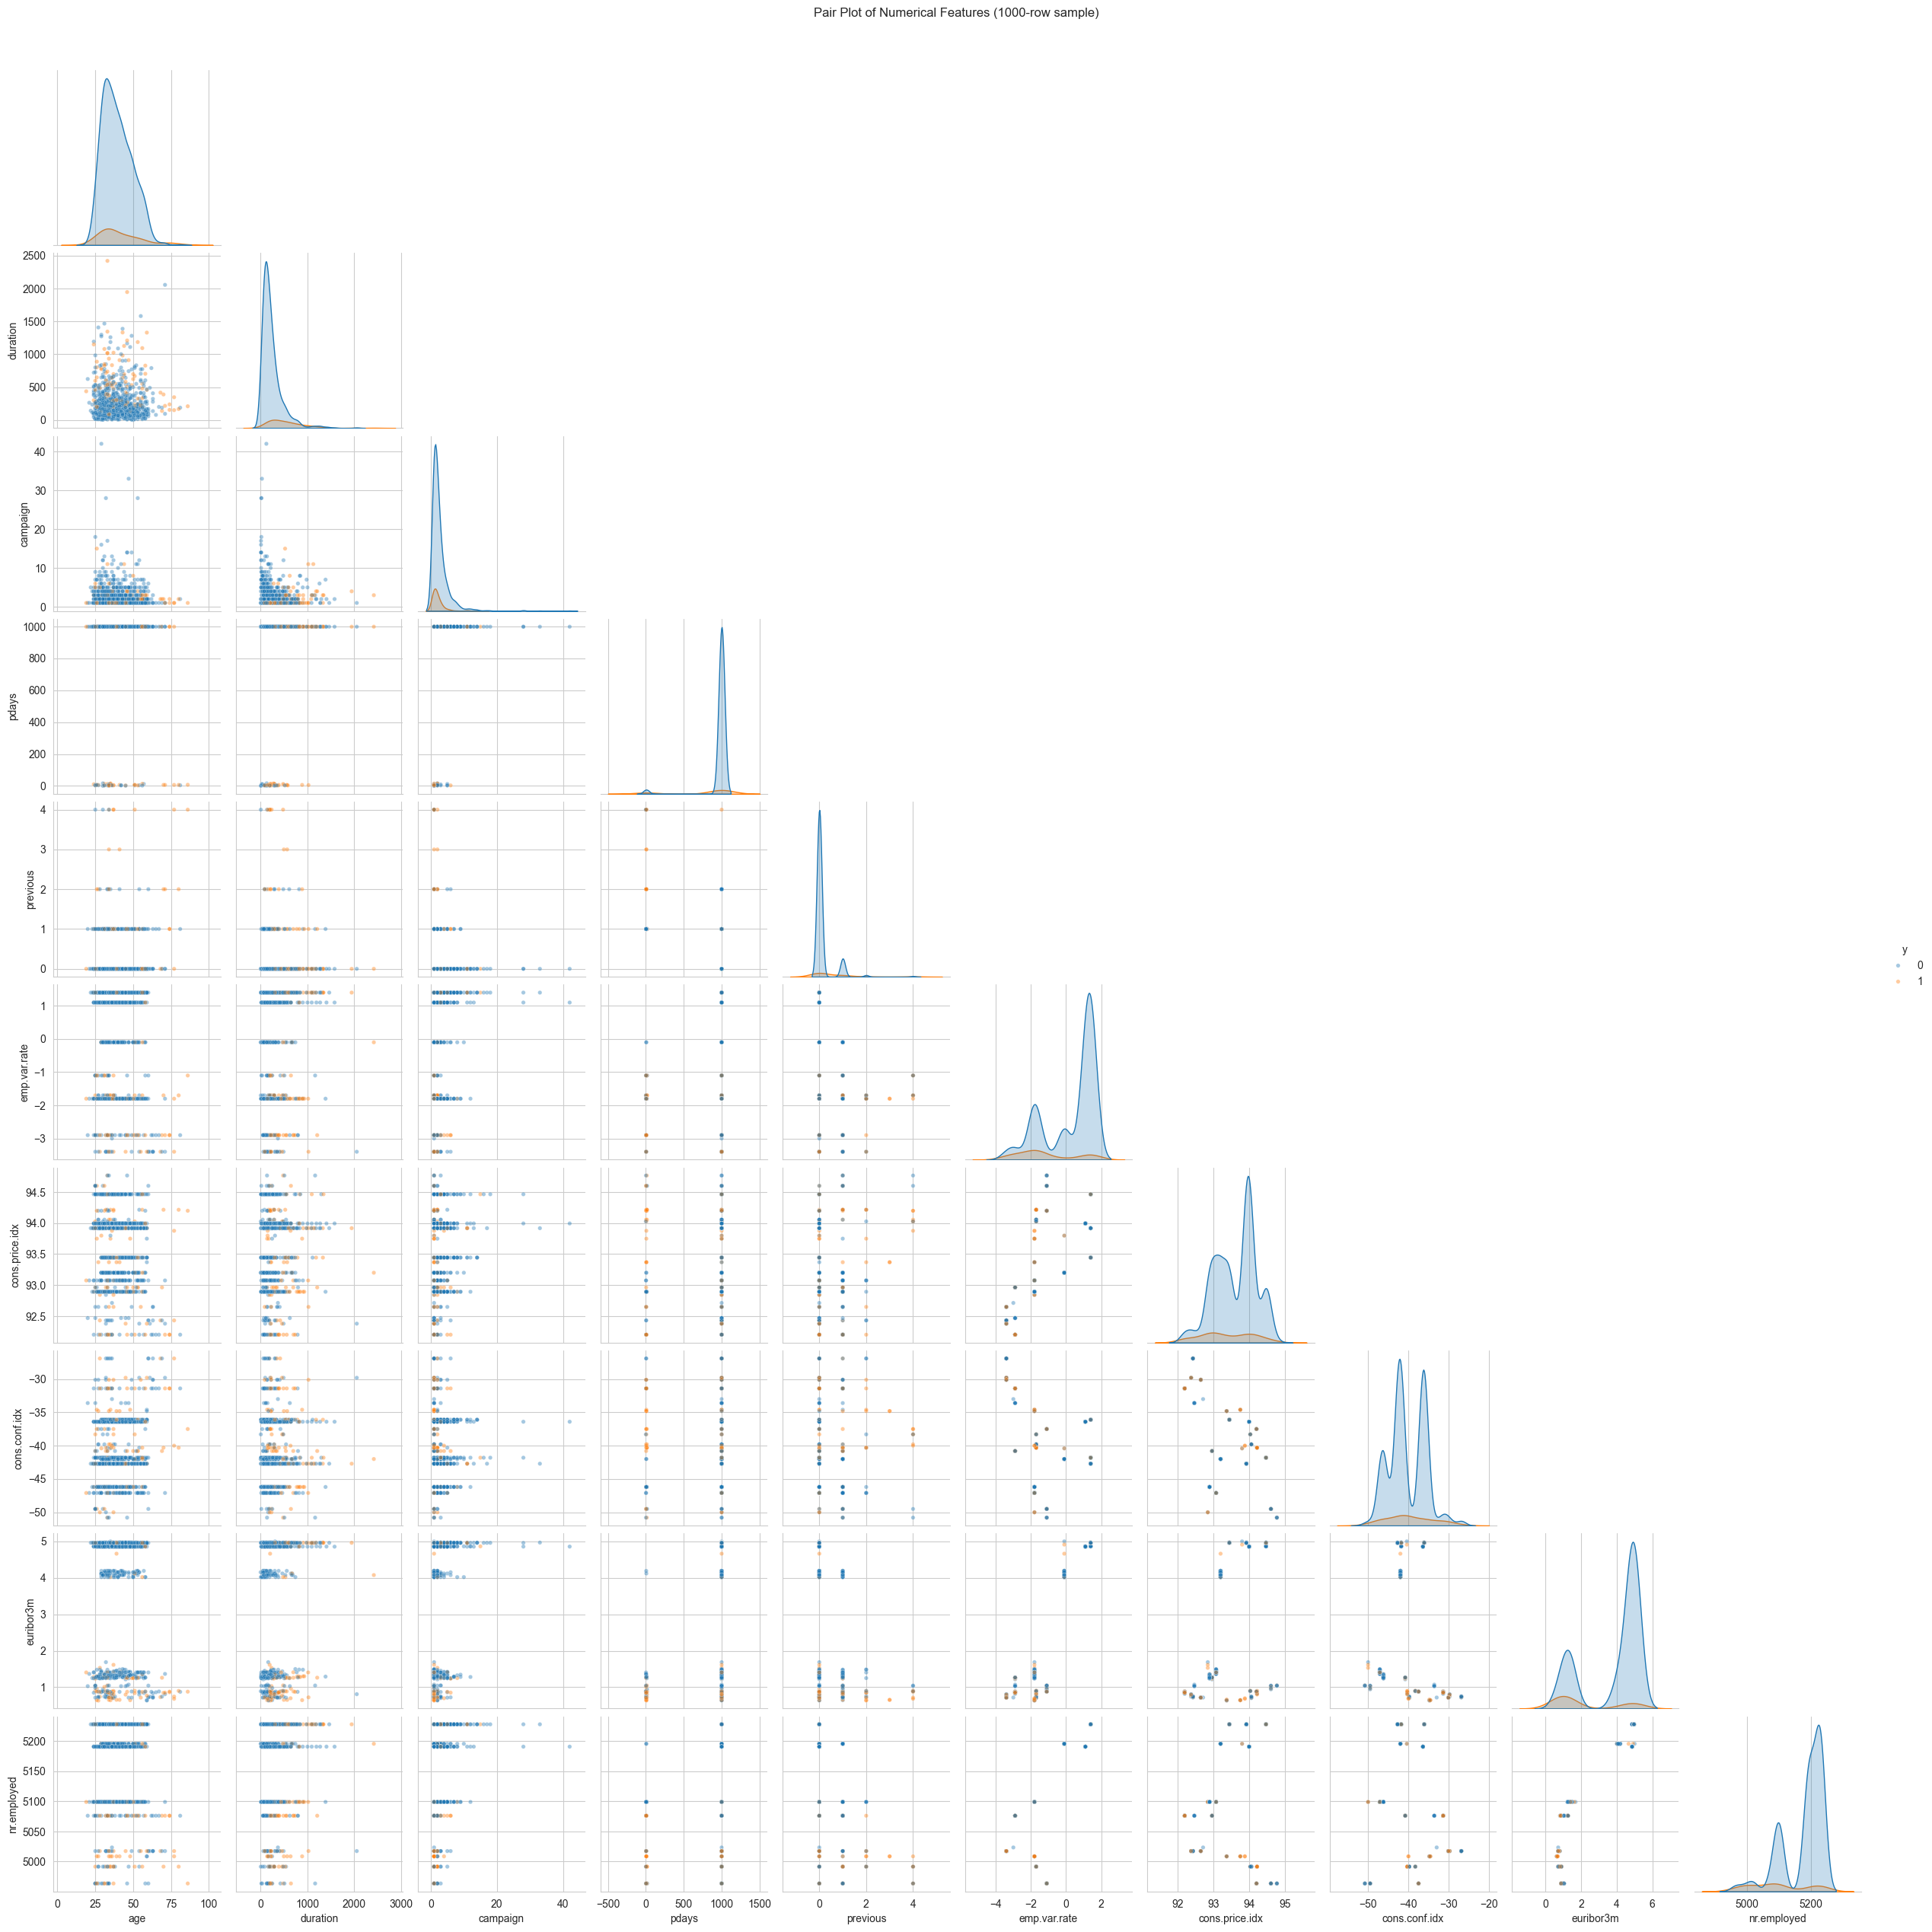

In [59]:
# The pair plot is informative but can be slow/large on the full dataset, so we use a
# small random sample. It is OPTIONAL: if it is skipped or fails, the notebook continues.
if RUN_PAIRPLOT:
    try:
        sample = df_eda.sample(min(PAIRPLOT_SAMPLE, len(df_eda)), random_state=RANDOM_SEED)
        g = sns.pairplot(sample[num_cols + [TARGET]], hue=TARGET,
                         plot_kws={"alpha": 0.4, "s": 15}, corner=True)
        g.fig.suptitle("Pair Plot of Numerical Features (1000-row sample)", y=1.02)
        save_fig("pairplot_numerical_features.png", fig=g.fig)
        plt.show()
    except Exception as e:
        print("Pair plot skipped (error):", e)
else:
    print("Pair plot skipped (RUN_PAIRPLOT = False).")

### 4.7 Categorical features vs. subscription rate

[saved figure] /Users/zcc/Documents/ukm/12Data mining/03 Project/outputs/figures/categorical_target_plots.png


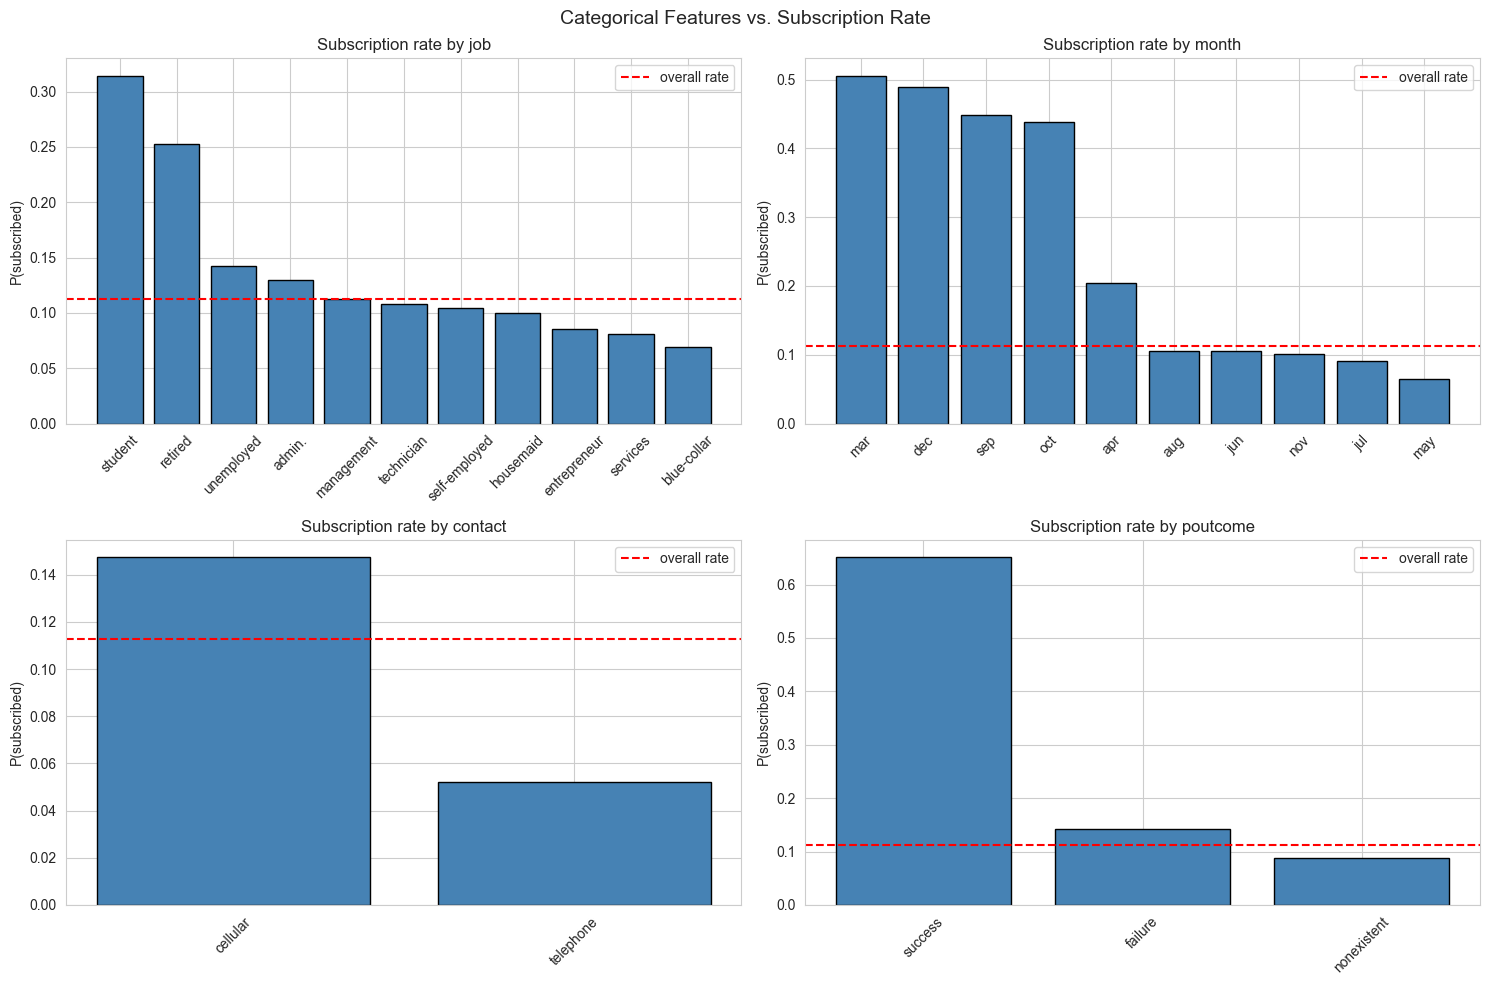

In [60]:
# For a few key categorical features, show the % of clients who subscribed in each
# category. The dashed line is the overall ~11% subscription rate for reference.
overall_rate = (df[TARGET] == "yes").mean()
cat_to_plot = ["job", "month", "contact", "poutcome"]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, col in zip(axes.flatten(), cat_to_plot):
    rate = (df.assign(_y=(df[TARGET] == "yes").astype(int))
              .groupby(col)["_y"].mean().sort_values(ascending=False))
    ax.bar(rate.index.astype(str), rate.values, color="steelblue", edgecolor="black")
    ax.axhline(overall_rate, color="red", linestyle="--", label="overall rate")
    ax.set_title(f"Subscription rate by {col}")
    ax.set_ylabel("P(subscribed)")
    ax.tick_params(axis="x", rotation=45)
    ax.legend()
plt.suptitle("Categorical Features vs. Subscription Rate", fontsize=14)
plt.tight_layout()
save_fig("categorical_target_plots.png")
plt.show()

**Note on `duration`:** *The duration feature is useful for understanding the dataset, but
it is excluded from the prediction model because it is only available after the call has
ended.*

## 5. Data Cleaning (safe steps only — no fitting yet)

These steps do **not** learn any statistics from the data, so they are safe to apply to
the whole dataset. The steps that DO learn (imputing, scaling, encoding, upsampling) come
later, **after** the train/test split.

Shape before removing duplicates: (41188, 21)
Shape after  removing duplicates: (41176, 21)
Rows removed: 12
Dropped columns: ['duration']
Added 'never_contacted' and replaced pdays sentinel 999 with median: 6.0
[saved figure] /Users/zcc/Documents/ukm/12Data mining/03 Project/outputs/figures/pdays_distribution.png


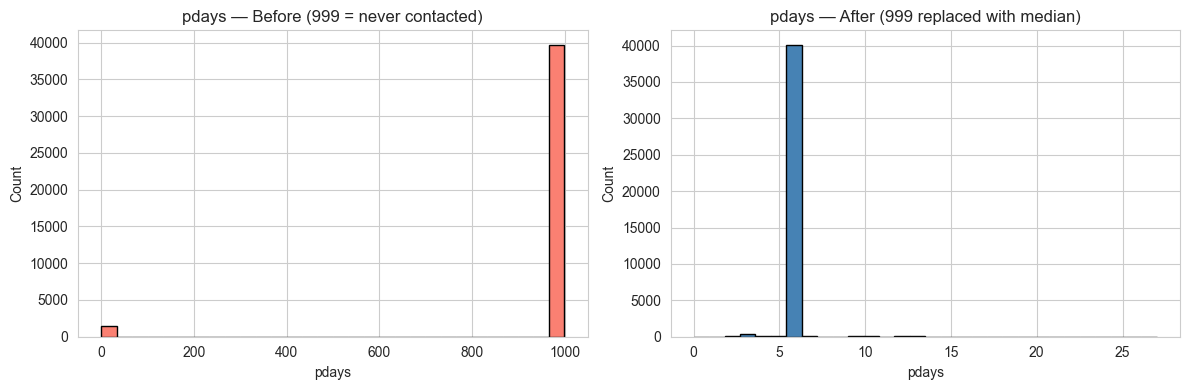

[saved figure] /Users/zcc/Documents/ukm/12Data mining/03 Project/outputs/figures/previous_log_transform.png


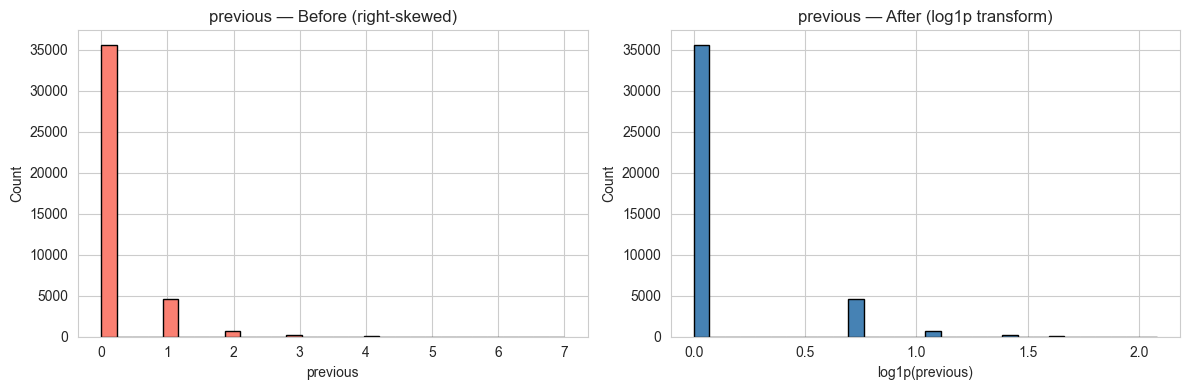

Clean shape: (41176, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,never_contacted
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,6,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,1
1,57,services,married,high.school,NaN,no,no,telephone,may,mon,...,6,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,1
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,6,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,1
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,6,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,1
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,6,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,1


In [61]:
df_clean = df.copy()    # df already has 'unknown' replaced by NaN

# 1) Remove exact duplicate rows (show shape before vs after)
before_shape = df_clean.shape
print(f"Shape before removing duplicates: {before_shape}")
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(f"Shape after  removing duplicates: {df_clean.shape}")
print(f"Rows removed: {before_shape[0] - df_clean.shape[0]}")

# 2) Drop the leakage column(s): duration
df_clean = df_clean.drop(columns=DROP_COLS)
print("Dropped columns:", DROP_COLS)

# 3) pdays feature engineering. The existing ColumnTransformer will treat the new
#    numeric columns automatically.
#    - 'never_contacted' flags clients who were never previously contacted.
#    - pdays == 999 is a SENTINEL value (not a real number of days), so we replace it with
#      the median of the REAL pdays values. This makes pdays numerically meaningful.
df_clean["never_contacted"] = (df_clean["pdays"] == 999).astype(int)
valid_pdays_median = df_clean.loc[df_clean["pdays"] != 999, "pdays"].median()
df_clean["pdays"] = df_clean["pdays"].replace(999, valid_pdays_median)
print("Added 'never_contacted' and replaced pdays sentinel 999 with median:", valid_pdays_median)

# pdays BEFORE vs AFTER the sentinel replacement
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["pdays"], bins=30, color="salmon", edgecolor="black")
axes[0].set_title("pdays — Before (999 = never contacted)")
axes[0].set_xlabel("pdays"); axes[0].set_ylabel("Count")
axes[1].hist(df_clean["pdays"], bins=30, color="steelblue", edgecolor="black")
axes[1].set_title("pdays — After (999 replaced with median)")
axes[1].set_xlabel("pdays"); axes[1].set_ylabel("Count")
plt.tight_layout()
save_fig("pdays_distribution.png")
plt.show()

# 4) Log-transform 'previous' (number of prior contacts). It is right-skewed, so log1p
#    compresses the long tail; this helps especially Logistic Regression.
df_clean["previous"] = np.log1p(df_clean["previous"])

# previous BEFORE vs AFTER the log transform
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["previous"], bins=30, color="salmon", edgecolor="black")
axes[0].set_title("previous — Before (right-skewed)")
axes[0].set_xlabel("previous"); axes[0].set_ylabel("Count")
axes[1].hist(df_clean["previous"], bins=30, color="steelblue", edgecolor="black")
axes[1].set_title("previous — After (log1p transform)")
axes[1].set_xlabel("log1p(previous)"); axes[1].set_ylabel("Count")
plt.tight_layout()
save_fig("previous_log_transform.png")
plt.show()

# 5) Encode the target: yes -> 1, no -> 0
df_clean[TARGET] = (df_clean[TARGET] == "yes").astype(int)

print("Clean shape:", df_clean.shape)
df_clean.head()

## 6. Train/Test Split — done BEFORE any preprocessing

This is the key step that prevents data leakage. We split first; then everything that
"learns" from data (imputers, scaler, encoder, upsampling) touches the **training set
only**. We use `stratify=y` so both sets start with the same ~11% "yes" rate.

In [62]:
X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,                 # keep the same class balance in both sets
    random_state=RANDOM_SEED,
)

# Save + print the train/test class distribution BEFORE upsampling
dist = pd.DataFrame({
    "class": [0, 1],
    "train_count": [int((y_train == 0).sum()), int((y_train == 1).sum())],
    "test_count":  [int((y_test == 0).sum()),  int((y_test == 1).sum())],
})
dist["train_percent"] = (dist["train_count"] / len(y_train) * 100).round(2)
dist["test_percent"]  = (dist["test_count"]  / len(y_test)  * 100).round(2)
save_table(dist, "class_distribution_train_test.csv")

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("\nClass distribution BEFORE upsampling:")
print(dist.to_string(index=False))

# Check: duration must NOT be among the modeling features
print("\n'duration' in modeling features?", "duration" in X_train.columns)
print("Modeling features:", X_train.columns.tolist())

[saved table]  /Users/zcc/Documents/ukm/12Data mining/03 Project/outputs/tables/class_distribution_train_test.csv
Train: (32940, 20) | Test: (8236, 20)

Class distribution BEFORE upsampling:
 class  train_count  test_count  train_percent  test_percent
     0        29229        7308          88.73         88.73
     1         3711         928          11.27         11.27

'duration' in modeling features? False
Modeling features: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'never_contacted']


## 7. Preprocessing (fit on training data only)

We build a `ColumnTransformer` that treats numeric and categorical columns differently,
and we **fit it on `X_train` only**, then merely *transform* both train and test — no
leakage.

- **Numeric:** fill missing with the median, then standardize (mean 0, std 1).
- **Categorical:** fill missing with the most frequent value, then one-hot encode.

We wrap it in a small `make_preprocessor()` factory so we can also build a *fresh* one
inside each cross-validation fold later.

In [63]:
# Detect column types automatically from the training features
numeric_features     = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(include="object").columns.tolist()
print("Numeric features    :", numeric_features)
print("Categorical features:", categorical_features)

def make_preprocessor():
    # Returns a NEW, unfitted ColumnTransformer (so each CV fold gets its own)
    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
    ])
    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    return ColumnTransformer([
        ("num", numeric_pipe,     numeric_features),
        ("cat", categorical_pipe, categorical_features),
    ])

# Fit the main preprocessor on the TRAINING data only, then transform both sets
preprocessor = make_preprocessor()
X_train_t = preprocessor.fit_transform(X_train)   # fit + transform on TRAIN
X_test_t  = preprocessor.transform(X_test)         # transform ONLY on TEST

feature_names = preprocessor.get_feature_names_out()
print("\nTransformed train shape:", X_train_t.shape)
print("Transformed test shape :", X_test_t.shape)
print("Number of features after one-hot encoding:", len(feature_names))

Numeric features    : ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'never_contacted']
Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

Transformed train shape: (32940, 57)
Transformed test shape : (8236, 57)
Number of features after one-hot encoding: 57


## 8. Handle Imbalance — SMOTE on the **training set only**

To stop the models from ignoring the rare "yes" class, we balance the classes with
**SMOTE (Synthetic Minority Over-sampling Technique)**. Instead of simply *duplicating*
existing minority rows, SMOTE **creates new, synthetic "yes" samples** by interpolating
between each minority point and its nearest minority neighbours. This adds variety rather
than exact copies, which usually helps the model generalise better than plain duplication.

**Why it is leakage-free:** we apply SMOTE **only to the transformed training data**. The
**test set is never touched** — it keeps its real ~11% "yes" rate, so our evaluation still
reflects the real world. Doing this *after* the split (and after fitting preprocessing on
train only) is what keeps the experiment honest.

[saved table]  /Users/zcc/Documents/ukm/12Data mining/03 Project/outputs/tables/class_distribution_after_train_upsampling.csv
Training set AFTER upsampling (should be 50/50):
 class  count  percent
     0  29229     50.0
     1  29229     50.0

Test set is UNCHANGED (still ~11% 'yes'):
  test class counts: {0: 7308, 1: 928}
  test 'yes' rate   : 11.27 %
[saved figure] /Users/zcc/Documents/ukm/12Data mining/03 Project/outputs/figures/smote_class_balance.png


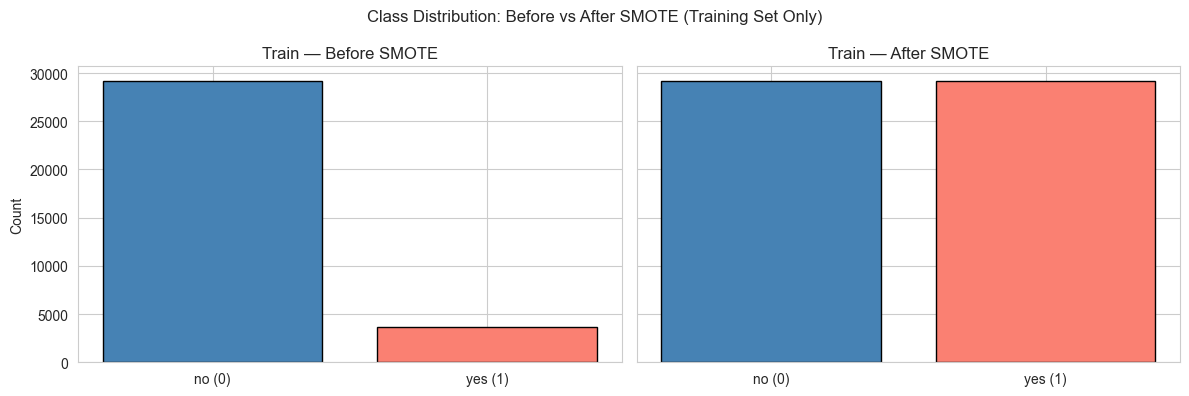

Note: Test set class distribution is NOT shown here — it remains unchanged at ~11% yes


In [64]:
# Generate synthetic minority samples with SMOTE — TRAINING data only.
# The test set (X_test_t, y_test) is never passed to SMOTE.
smote = SMOTE(k_neighbors=SMOTE_K_NEIGHBORS, random_state=RANDOM_SEED)
X_train_bal, y_train_bal = smote.fit_resample(X_train_t, y_train)
y_train_bal = np.asarray(y_train_bal)

# Save + print the training distribution AFTER upsampling
after = pd.DataFrame({
    "class": [0, 1],
    "count": [int((y_train_bal == 0).sum()), int((y_train_bal == 1).sum())],
})
after["percent"] = (after["count"] / len(y_train_bal) * 100).round(2)
save_table(after, "class_distribution_after_train_upsampling.csv")

print("Training set AFTER upsampling (should be 50/50):")
print(after.to_string(index=False))
print("\nTest set is UNCHANGED (still ~11% 'yes'):")
print("  test class counts:", {0: int((y_test == 0).sum()), 1: int((y_test == 1).sum())})
print("  test 'yes' rate   :", round(y_test.mean() * 100, 2), "%")

# Class balance BEFORE vs AFTER SMOTE (training set only)
before_counts = pd.Series(np.asarray(y_train)).value_counts().sort_index()
after_counts  = pd.Series(np.asarray(y_train_bal)).value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].bar(["no (0)", "yes (1)"], before_counts.values, color=["steelblue", "salmon"], edgecolor="black")
axes[0].set_title("Train — Before SMOTE")
axes[0].set_ylabel("Count")
axes[1].bar(["no (0)", "yes (1)"], after_counts.values, color=["steelblue", "salmon"], edgecolor="black")
axes[1].set_title("Train — After SMOTE")
plt.suptitle("Class Distribution: Before vs After SMOTE (Training Set Only)")
plt.tight_layout()
save_fig("smote_class_balance.png")
plt.show()

# Note: Test set class distribution is NOT shown here — it remains unchanged at ~11% yes.
print("Note: Test set class distribution is NOT shown here — it remains unchanged at ~11% yes")

## 9. Define the Two Models

Plain classifiers (no `class_weight`, since the training data is already balanced by
upsampling). We keep them in a dictionary so we can train and compare them in a loop.

In [65]:
models = {
    "Logistic Regression": LogisticRegression(**LOGREG_PARAMS),
    "Random Forest":       RandomForestClassifier(**RF_PARAMS),
}
model_keys = {"Logistic Regression": "logreg", "Random Forest": "rf"}  # for file names
for name in models:
    print("Defined:", name)

Defined: Logistic Regression
Defined: Random Forest


## 10. Cross-Validation (training set only, upsampling inside each fold)

Before the final test, we estimate how well each model generalizes using **5-fold
stratified cross-validation** on the training data. To stay leakage-free, inside **each
fold** we: fit a fresh preprocessor on that fold's training part, transform, apply
**SMOTE to only that fold's training part**, then score on the held-out validation part
(which is *not* resampled). We report F1 and ROC-AUC.

In [66]:
def cross_validate_upsampled(make_model, X, y):
    # Simple, readable manual CV that applies SMOTE only to the training part of each fold.
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)
    f1_scores, auc_scores = [], []
    for train_idx, val_idx in cv.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        prep = make_preprocessor()                 # fresh, unfitted
        X_tr_t  = prep.fit_transform(X_tr)          # fit on fold-train only
        X_val_t = prep.transform(X_val)             # transform fold-val
        sm = SMOTE(k_neighbors=SMOTE_K_NEIGHBORS, random_state=RANDOM_SEED)
        X_tr_b, y_tr_b = sm.fit_resample(X_tr_t, y_tr)  # SMOTE on fold-train only

        model = make_model()
        model.fit(X_tr_b, y_tr_b)
        pred = model.predict(X_val_t)
        prob = model.predict_proba(X_val_t)[:, 1]
        f1_scores.append(f1_score(y_val, pred))
        auc_scores.append(roc_auc_score(y_val, prob))
    return np.array(f1_scores), np.array(auc_scores)

# Explicit dispatch (avoids the late-binding closure bug a loop-assigned lambda would have)
makers = {
    "Logistic Regression": lambda: LogisticRegression(**LOGREG_PARAMS),
    "Random Forest":       lambda: RandomForestClassifier(**RF_PARAMS),
}
cv_rows = []
for name in models:
    f1s, aucs = cross_validate_upsampled(makers[name], X_train, y_train)
    cv_rows.append({
        "Model": name,
        "CV F1 mean": f1s.mean(), "CV F1 std": f1s.std(),
        "CV AUC mean": aucs.mean(), "CV AUC std": aucs.std(),
    })

cv_df = pd.DataFrame(cv_rows).round(4)
save_table(cv_df, "cv_scores.csv")
cv_df

[saved table]  /Users/zcc/Documents/ukm/12Data mining/03 Project/outputs/tables/cv_scores.csv


,Model,CV F1 mean,CV F1 std,CV AUC mean,CV AUC std
0,Logistic Regression,0.4443,0.0105,0.7881,0.0074
1,Random Forest,0.4790,0.0060,0.7899,0.0071


## 11. Train on the Upsampled Training Set & Evaluate on the Untouched Test Set

Now we train each model on the **balanced training data** and evaluate once on the
**original (un-upsampled) test set** — our honest estimate of real-world performance.

In [67]:
# Train each model on the upsampled training data
for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    print("Trained:", name)

# Collect test-set metrics (test set is NOT upsampled)
results = []
for name, model in models.items():
    y_pred = model.predict(X_test_t)
    y_prob = model.predict_proba(X_test_t)[:, 1]
    results.append({
        "Model":     name,
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall":    recall_score(y_test, y_pred),
        "F1 Score":  f1_score(y_test, y_pred),
        "ROC-AUC":   roc_auc_score(y_test, y_prob),
    })

results_df = pd.DataFrame(results).round(4)
save_table(results_df, "model_metrics.csv")
results_df

Trained: Logistic Regression
Trained: Random Forest
[saved table]  /Users/zcc/Documents/ukm/12Data mining/03 Project/outputs/tables/model_metrics.csv


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8271,0.3546,0.6519,0.4594,0.7971
1,Random Forest,0.8912,0.5177,0.5054,0.5115,0.7996


In [68]:
# Business-oriented metrics: Sensitivity (Recall) and Specificity, from the test-set
# confusion matrix of each model.
business_rows = []
for name, model in models.items():
    y_pred = model.predict(X_test_t)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    sensitivity = tp / (tp + fn)     # = Recall: real subscribers we catch
    specificity = tn / (tn + fp)     # non-subscribers we correctly avoid
    business_rows.append({"Model": name,
                          "Sensitivity": sensitivity,
                          "Specificity": specificity})

business_metrics_df = pd.DataFrame(business_rows).round(4)
save_table(business_metrics_df, "business_metrics.csv")
print("Business metrics (test set):")
business_metrics_df

[saved table]  /Users/zcc/Documents/ukm/12Data mining/03 Project/outputs/tables/business_metrics.csv
Business metrics (test set):


,Model,Sensitivity,Specificity
0,Logistic Regression,0.6519,0.8493
1,Random Forest,0.5054,0.9402


**Sensitivity** measures how many real subscribers the model catches.
**Specificity** measures how many non-subscribers are correctly avoided.
For a bank campaign, high Sensitivity means fewer missed opportunities, while high
Specificity means fewer wasted calls.

[saved table]  /Users/zcc/Documents/ukm/12Data mining/03 Project/outputs/tables/confusion_matrix_logreg.csv
[saved table]  /Users/zcc/Documents/ukm/12Data mining/03 Project/outputs/tables/confusion_matrix_rf.csv
[saved figure] /Users/zcc/Documents/ukm/12Data mining/03 Project/outputs/figures/confusion_matrices.png


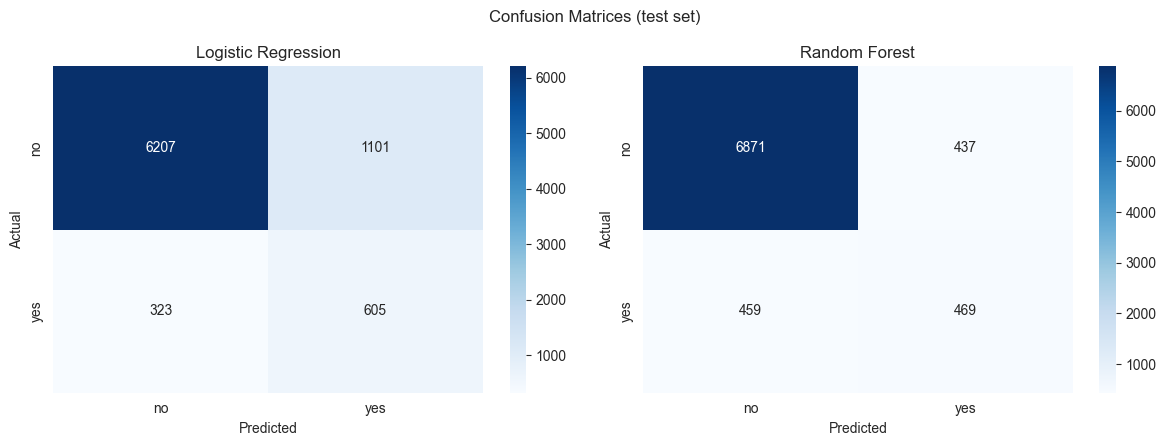

In [69]:
# Confusion matrices (rows = actual, columns = predicted)
fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 4.5))
for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test_t)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["no", "yes"], yticklabels=["no", "yes"])
    ax.set_title(name); ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    cm_df = pd.DataFrame(cm, index=["actual_no", "actual_yes"],
                         columns=["pred_no", "pred_yes"])
    save_table(cm_df, f"confusion_matrix_{model_keys[name]}.csv", index=True)
plt.suptitle("Confusion Matrices (test set)")
plt.tight_layout()
save_fig("confusion_matrices.png")
plt.show()

In [70]:
# Detailed per-class precision/recall/F1 for each model
from sklearn.metrics import classification_report

for name, model in models.items():
    y_pred = model.predict(X_test_t)
    print(f"Classification Report — {name}")
    print(classification_report(y_test, y_pred, target_names=["no (0)", "yes (1)"]))
    print()

Classification Report — Logistic Regression
              precision    recall  f1-score   support

      no (0)       0.95      0.85      0.90      7308
     yes (1)       0.35      0.65      0.46       928

    accuracy                           0.83      8236
   macro avg       0.65      0.75      0.68      8236
weighted avg       0.88      0.83      0.85      8236


Classification Report — Random Forest
              precision    recall  f1-score   support

      no (0)       0.94      0.94      0.94      7308
     yes (1)       0.52      0.51      0.51       928

    accuracy                           0.89      8236
   macro avg       0.73      0.72      0.73      8236
weighted avg       0.89      0.89      0.89      8236




[saved figure] /Users/zcc/Documents/ukm/12Data mining/03 Project/outputs/figures/roc_curves.png


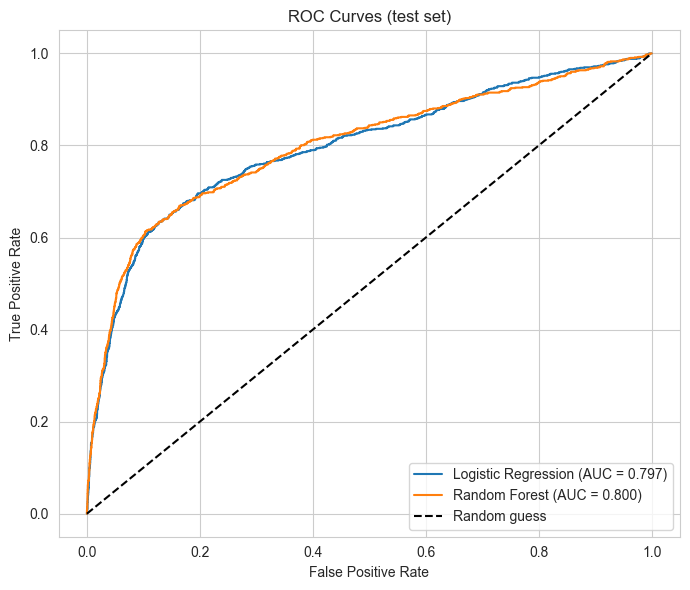

In [71]:
# ROC curves — higher/left-er is better; the diagonal is random guessing
plt.figure(figsize=(7, 6))
for name, model in models.items():
    y_prob = model.predict_proba(X_test_t)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves (test set)"); plt.legend(loc="lower right")
plt.tight_layout()
save_fig("roc_curves.png")
plt.show()

[saved figure] /Users/zcc/Documents/ukm/12Data mining/03 Project/outputs/figures/model_comparison.png


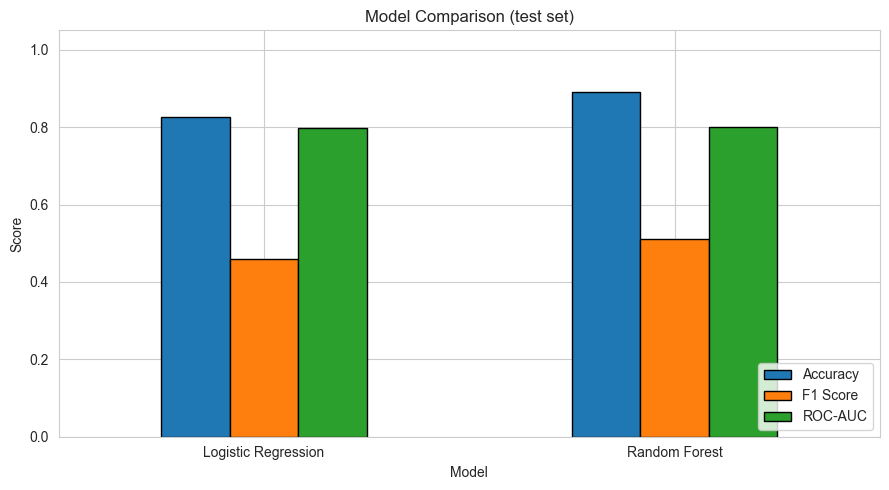

In [72]:
# Side-by-side comparison of the headline metrics
results_df.set_index("Model")[["Accuracy", "F1 Score", "ROC-AUC"]].plot(
    kind="bar", figsize=(9, 5), edgecolor="black")
plt.title("Model Comparison (test set)")
plt.ylabel("Score"); plt.ylim(0, 1.05); plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
save_fig("model_comparison.png")
plt.show()

### 11b. Threshold Tuning (Random Forest)

By default a classifier predicts "yes" when its probability is ≥ **0.50**. We can move
this cut-off. **Lowering the threshold (here to `THRESHOLD`) increases Recall at the cost of
Precision** — useful when *missing* a potential subscriber is more costly than making a
wasted call. The ROC-AUC does not change (it does not depend on the threshold); only the
yes/no decisions do.

In [73]:
# Use Random Forest probabilities, then compare the default 0.50 cut-off with THRESHOLD.
rf = models["Random Forest"]
rf_prob = rf.predict_proba(X_test_t)[:, 1]

def metrics_at(threshold):
    pred = (rf_prob >= threshold).astype(int)
    return {
        "Threshold": threshold,
        "Accuracy":  accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall":    recall_score(y_test, pred),
        "F1 Score":  f1_score(y_test, pred),
        "ROC-AUC":   roc_auc_score(y_test, rf_prob),   # same regardless of threshold
    }

threshold_df = pd.DataFrame([metrics_at(0.50), metrics_at(THRESHOLD)]).round(4)
save_table(threshold_df, "model_metrics_threshold_tuned.csv")
print("Random Forest — effect of lowering the decision threshold:")
threshold_df

[saved table]  /Users/zcc/Documents/ukm/12Data mining/03 Project/outputs/tables/model_metrics_threshold_tuned.csv
Random Forest — effect of lowering the decision threshold:


,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,0.50,0.8912,0.5177,0.5054,0.5115,0.7996
1,0.35,0.8611,0.4206,0.6164,0.5000,0.7996


## 12. Model Interpretation

Which features drive the predictions? We look at Random Forest **feature importances**
and Logistic Regression **coefficients**, using the (one-hot expanded) feature names from
the fitted preprocessor.

[saved table]  /Users/zcc/Documents/ukm/12Data mining/03 Project/outputs/tables/rf_feature_importances.csv
[saved figure] /Users/zcc/Documents/ukm/12Data mining/03 Project/outputs/figures/rf_feature_importances.png


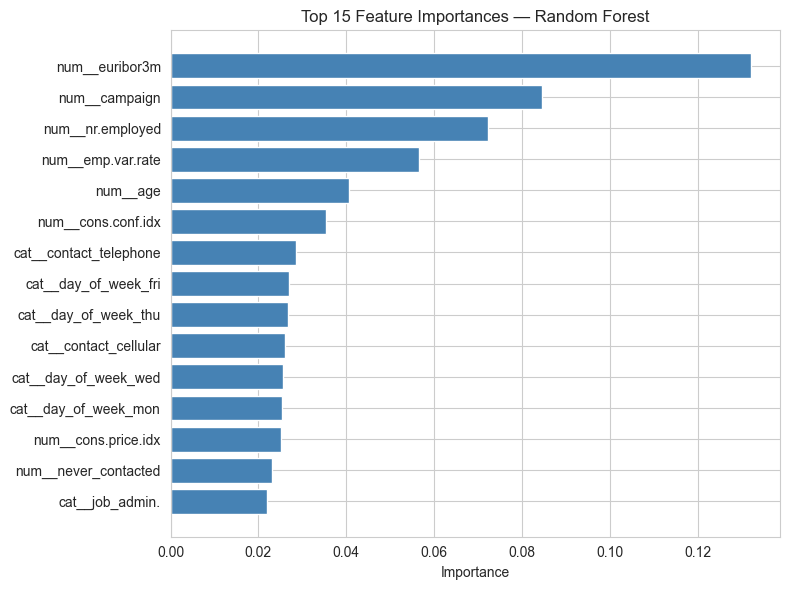

,feature,importance
0,num__euribor3m,0.132150
1,num__campaign,0.084666
2,num__nr.employed,0.072205
3,num__emp.var.rate,0.056661
4,num__age,0.040712
5,num__cons.conf.idx,0.035448
6,cat__contact_telephone,0.028551
7,cat__day_of_week_fri,0.027006
8,cat__day_of_week_thu,0.026811
9,cat__contact_cellular,0.025946


In [74]:
# --- Random Forest feature importances ---
rf = models["Random Forest"]
importances = (pd.DataFrame({"feature": feature_names,
                             "importance": rf.feature_importances_})
               .sort_values("importance", ascending=False)
               .reset_index(drop=True))
save_table(importances, "rf_feature_importances.csv")

plt.figure(figsize=(8, 6))
top = importances.head(15).iloc[::-1]
plt.barh(top["feature"], top["importance"], color="steelblue")
plt.title("Top 15 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
save_fig("rf_feature_importances.png")
plt.show()

importances.head(15)

[saved table]  /Users/zcc/Documents/ukm/12Data mining/03 Project/outputs/tables/logreg_coefficients.csv
[saved figure] /Users/zcc/Documents/ukm/12Data mining/03 Project/outputs/figures/logreg_coefficients.png


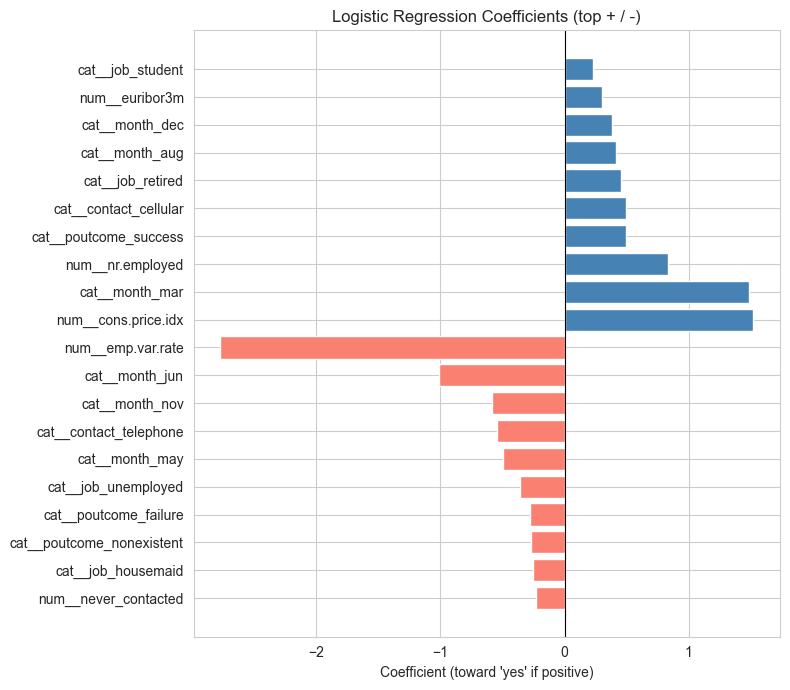

,feature,coefficient
0,num__cons.price.idx,1.521488
1,cat__month_mar,1.485886
2,num__nr.employed,0.834937
3,cat__poutcome_success,0.495257
4,cat__contact_cellular,0.493480
5,cat__job_retired,0.453704
6,cat__month_aug,0.418910
7,cat__month_dec,0.385137
8,num__euribor3m,0.303492
9,cat__job_student,0.226215


In [75]:
# --- Logistic Regression coefficients ---
# Positive coefficient -> pushes prediction toward "yes"; negative -> toward "no".
lr = models["Logistic Regression"]
coefs = (pd.DataFrame({"feature": feature_names, "coefficient": lr.coef_[0]})
         .sort_values("coefficient", ascending=False)
         .reset_index(drop=True))
save_table(coefs, "logreg_coefficients.csv")

top_pos = coefs.head(10)
top_neg = coefs.tail(10)
plot_df = pd.concat([top_neg, top_pos]).set_index("feature")

plt.figure(figsize=(8, 7))
colors = ["salmon" if c < 0 else "steelblue" for c in plot_df["coefficient"]]
plt.barh(plot_df.index, plot_df["coefficient"], color=colors)
plt.title("Logistic Regression Coefficients (top + / -)")
plt.xlabel("Coefficient (toward 'yes' if positive)")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
save_fig("logreg_coefficients.png")
plt.show()

coefs.head(10)